##### EPMT Data "Cleanup" - Next Idea No. "11" (More data - 100k+ rows)

Following up from EPMTDataCleanup_Next7.ipynb<br>

- validation set r_squared = 0.38
- test set r_squared = 0.42

In [1]:
%pip install pandas matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pprint
import ast
from datetime import datetime

%matplotlib inline 

# Suggested by Gemini -- "Makes your plots look a bit more modern/clean"
sns.set_theme(style="whitegrid")

# Load some data and revisit what we have so far

In [3]:
import glob
import os

data_path = 'epmt_data_cleaned_20260326_074338.csv'

df = pd.read_csv(data_path)

In [4]:
df.columns.tolist()

['cpu_time',
 'SLURM_JOB_ACCOUNT',
 'exp_component',
 'exp_name',
 'exp_time',
 'exp_platform',
 'exp_target',
 'exp_seg_months']

In [5]:
len(df)

106447

## Pre-Processing: One-hot encoding
* Including one-hot encoding (from categorial to numerical) to all data
* Specialized reduction of categories (Example: reducing the number of exp_component cateogories)
* I'm not standardizing or normalizing data yet.

In [6]:
from sklearn.preprocessing import OneHotEncoder

In [7]:
category_cols = df.select_dtypes(exclude="number").columns.tolist()
df[category_cols].head()

,SLURM_JOB_ACCOUNT,exp_component,exp_name,exp_platform,exp_target
0,gfdl_m,atmos_level,c96L65_am5f8d6r3_pdclim2010F_cosp_CPE2_ens0085,gfdl.ncrc5-intel23-classic,prod-openmp
1,gfdl_m,atmos,c96L65_am5f8d6r3_pdclim2010F_cosp_CPE2_ens0066,gfdl.ncrc5-intel23-classic,prod-openmp
2,gfdl_w,refineDiag,c96L65_am5f8d5r0z_amip_wuopt1,gfdl.ncrc5-intel23-classic,prod-openmp
3,gfdl_m,atmos_month_aer,c96L65_am5f8d6r3_pdclim2010F_cosp_CPE2_ens0085,gfdl.ncrc5-intel23-classic,prod-openmp
4,gfdl_m,atmos_level_cmip,c96L65_am5f8d6r3_pdclim2010F_cosp_CPE2_ens0066,gfdl.ncrc5-intel23-classic,prod-openmp


In [8]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
df[numeric_cols].head()

,cpu_time,exp_time,exp_seg_months
0,1.297620e+09,10101,12
1,1.527381e+09,10101,12
2,3.506743e+08,19980101,12
3,6.541279e+08,10101,12
4,5.257977e+08,10101,12


In [9]:
easy_categories=['SLURM_JOB_ACCOUNT', 'exp_target', 'exp_platform']
ohe = OneHotEncoder(sparse_output=False)
ohe_data = ohe.fit_transform(df[easy_categories])
ohe_cols = ohe.get_feature_names_out(easy_categories)
df_categorical = pd.DataFrame(ohe_data, columns=ohe_cols)
df_categorical.head()

,SLURM_JOB_ACCOUNT_cefi,SLURM_JOB_ACCOUNT_gfdl_a,SLURM_JOB_ACCOUNT_gfdl_b,SLURM_JOB_ACCOUNT_gfdl_f,SLURM_JOB_ACCOUNT_gfdl_m,SLURM_JOB_ACCOUNT_gfdl_o,SLURM_JOB_ACCOUNT_gfdl_sd,SLURM_JOB_ACCOUNT_gfdl_w,exp_target_prod,"exp_target_prod,hdf5",...,exp_platform_gfdl.ncrc5-intel22,exp_platform_gfdl.ncrc5-intel23,exp_platform_gfdl.ncrc5-intel23-classic,exp_platform_gfdl.ncrc5-intel23_2_0,exp_platform_gfdl.ncrc5-intel25,exp_platform_gfdl.ncrc5-intel25-MM,exp_platform_gfdl.ncrc5-inteloneapi252,exp_platform_gfdl.ncrc6-intel23,exp_platform_gfdl.ncrc6-intel23_2_0,exp_platform_gfdl.ncrc6-intel25
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


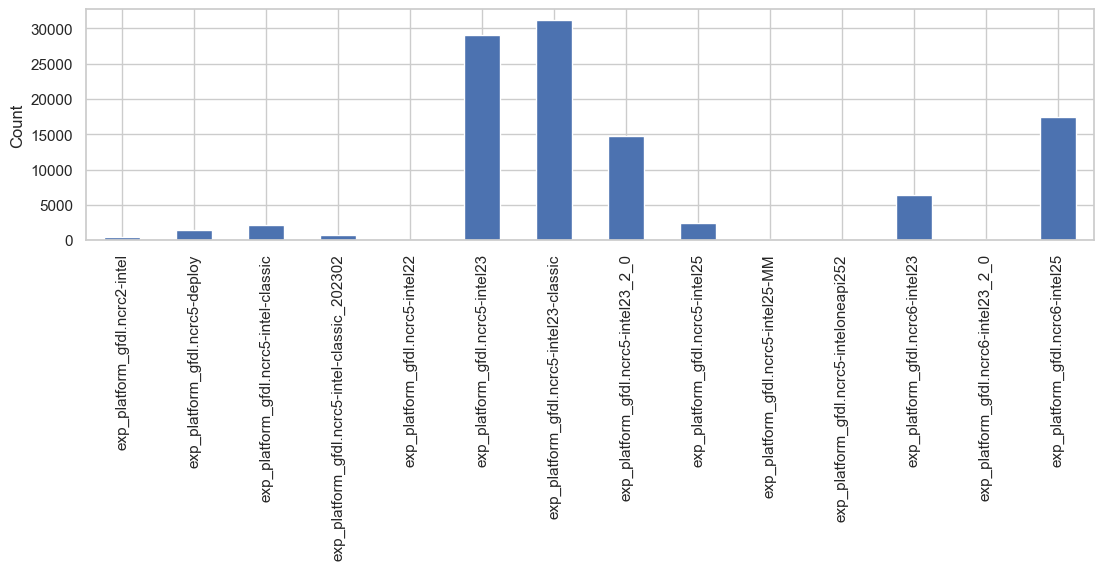

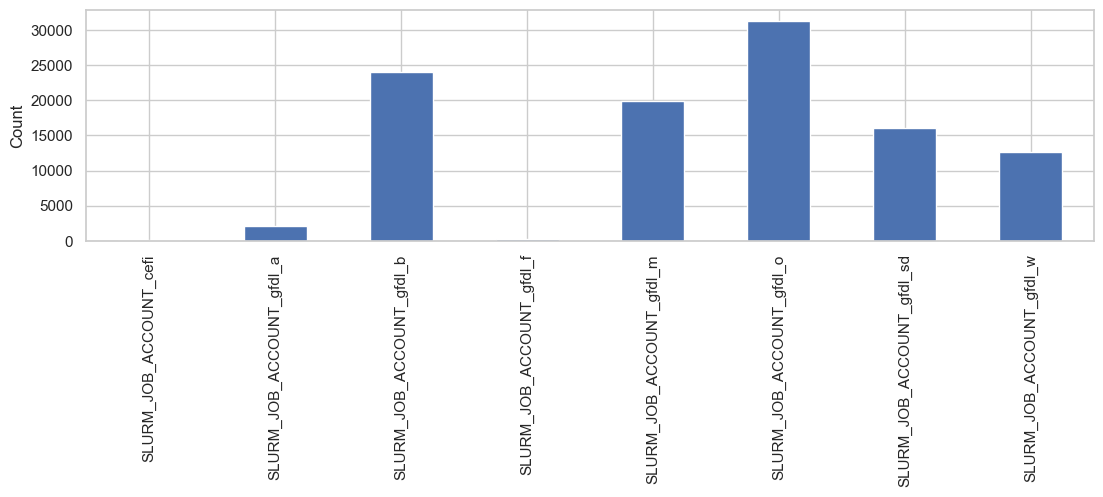

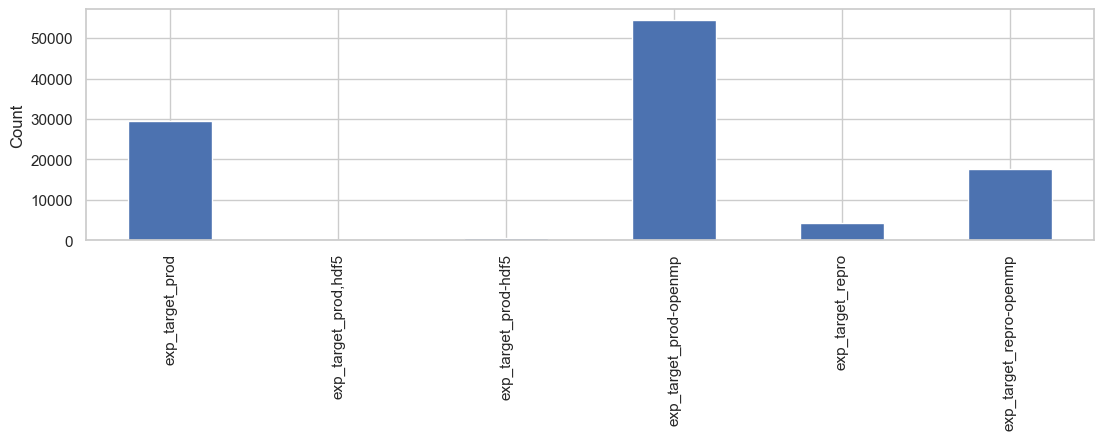

In [10]:
def plot_one_category(df_categorical, single_category):
    startswith = f"{single_category}_"
    cols = [c for c in df_categorical.columns if c.startswith(startswith)]
    df_categorical[cols].sum().plot(kind='bar', figsize=(13,3))
    plt.ylabel('Count')
    plt.show()
    
plot_one_category(df_categorical, "exp_platform")
plot_one_category(df_categorical, "SLURM_JOB_ACCOUNT")
plot_one_category(df_categorical, "exp_target")

In [11]:
# The remaining categories are exp_component and exp_name.

In [12]:
# Try to reduce the cardinality of the exp_component - just take the first part
df['exp_component'] = df['exp_component'].str.split('_').str[0].fillna("None")

In [13]:
expcomp_data = ohe.fit_transform(df[['exp_component']])
expcomp_cols = ohe.get_feature_names_out(['exp_component'])
df_expcomp = pd.DataFrame(expcomp_data, columns=expcomp_cols)
df_expcomp.head()

,exp_component_LUmip,exp_component_None,exp_component_aerosol,exp_component_atmos,exp_component_drydep,exp_component_fire,exp_component_ice,exp_component_iceberg,exp_component_land,exp_component_lu,exp_component_ocean,exp_component_refineDiag,exp_component_river,exp_component_soil,exp_component_tracer
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


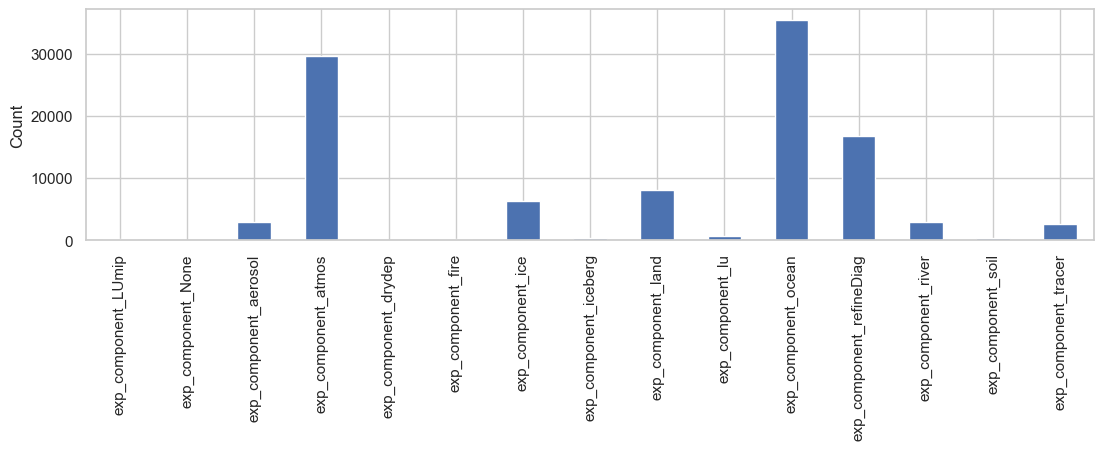

In [14]:
plot_one_category(df_expcomp, "exp_component")

In [15]:
df = pd.concat([df, df_categorical, df_expcomp], axis=1)

In [16]:
df = df.drop(columns=['exp_component', 'exp_target'])

## Handle exp_name

In [17]:
# Try to reduce the cardinality of the script_name - find the c96, c12, etc...
c_matches = df['exp_name'].str.findall(r'[cC]\d+')
c_matches_unique = c_matches.explode().dropna().unique()
c_matches_unique_lower = [s.lower() for s in c_matches_unique]
c_matches_unique_lower

['c96', 'c384', 'c0101', 'c0', 'c192', 'c384', 'c5', 'c1982', 'c12']

In [18]:
c_matches.explode().value_counts()

exp_name
c96      33530
c384      7351
c192      5731
C1982     4059
C0101     1941
c5         664
C384       162
c0          88
C12         38
Name: count, dtype: int64

In [19]:
# Create columns corresponding to those unique matches, and basically one-hot encode using them as new column names
for pattern in c_matches_unique_lower:
    df[pattern] = df['exp_name'].apply(
        lambda x: 1 if isinstance(x, str) and pattern in x.lower() else 0
    )

# Create the 'c_unknown' column
# If the sum of all the pattern columns we just created is 0, it's unknown
df['c_unknown'] = (df[c_matches_unique_lower].sum(axis=1) == 0).astype(int)

df.head()

,cpu_time,SLURM_JOB_ACCOUNT,exp_name,exp_time,exp_platform,exp_seg_months,SLURM_JOB_ACCOUNT_cefi,SLURM_JOB_ACCOUNT_gfdl_a,SLURM_JOB_ACCOUNT_gfdl_b,SLURM_JOB_ACCOUNT_gfdl_f,...,exp_component_tracer,c96,c384,c0101,c0,c192,c5,c1982,c12,c_unknown
0,1.297620e+09,gfdl_m,c96L65_am5f8d6r3_pdclim2010F_cosp_CPE2_ens0085,10101,gfdl.ncrc5-intel23-classic,12,0.0,0.0,0.0,0.0,...,0.0,1,0,0,0,0,0,0,0,0
1,1.527381e+09,gfdl_m,c96L65_am5f8d6r3_pdclim2010F_cosp_CPE2_ens0066,10101,gfdl.ncrc5-intel23-classic,12,0.0,0.0,0.0,0.0,...,0.0,1,0,0,0,0,0,0,0,0
2,3.506743e+08,gfdl_w,c96L65_am5f8d5r0z_amip_wuopt1,19980101,gfdl.ncrc5-intel23-classic,12,0.0,0.0,0.0,0.0,...,0.0,1,0,0,0,0,0,0,0,0
3,6.541279e+08,gfdl_m,c96L65_am5f8d6r3_pdclim2010F_cosp_CPE2_ens0085,10101,gfdl.ncrc5-intel23-classic,12,0.0,0.0,0.0,0.0,...,0.0,1,0,0,0,0,0,0,0,0
4,5.257977e+08,gfdl_m,c96L65_am5f8d6r3_pdclim2010F_cosp_CPE2_ens0066,10101,gfdl.ncrc5-intel23-classic,12,0.0,0.0,0.0,0.0,...,0.0,1,0,0,0,0,0,0,0,0


In [20]:
# Rename these columns. 'cXX' becomes 'c_XX'
for col in ['c96', 'c384', 'c0101', 'c0', 'c192', 'c5', 'c1982', 'c12']:
    new_name = "c_" + col[1:] 
    df.rename(columns={col: new_name}, inplace=True)
df.head()

,cpu_time,SLURM_JOB_ACCOUNT,exp_name,exp_time,exp_platform,exp_seg_months,SLURM_JOB_ACCOUNT_cefi,SLURM_JOB_ACCOUNT_gfdl_a,SLURM_JOB_ACCOUNT_gfdl_b,SLURM_JOB_ACCOUNT_gfdl_f,...,exp_component_tracer,c_96,c_384,c_0101,c_0,c_192,c_5,c_1982,c_12,c_unknown
0,1.297620e+09,gfdl_m,c96L65_am5f8d6r3_pdclim2010F_cosp_CPE2_ens0085,10101,gfdl.ncrc5-intel23-classic,12,0.0,0.0,0.0,0.0,...,0.0,1,0,0,0,0,0,0,0,0
1,1.527381e+09,gfdl_m,c96L65_am5f8d6r3_pdclim2010F_cosp_CPE2_ens0066,10101,gfdl.ncrc5-intel23-classic,12,0.0,0.0,0.0,0.0,...,0.0,1,0,0,0,0,0,0,0,0
2,3.506743e+08,gfdl_w,c96L65_am5f8d5r0z_amip_wuopt1,19980101,gfdl.ncrc5-intel23-classic,12,0.0,0.0,0.0,0.0,...,0.0,1,0,0,0,0,0,0,0,0
3,6.541279e+08,gfdl_m,c96L65_am5f8d6r3_pdclim2010F_cosp_CPE2_ens0085,10101,gfdl.ncrc5-intel23-classic,12,0.0,0.0,0.0,0.0,...,0.0,1,0,0,0,0,0,0,0,0
4,5.257977e+08,gfdl_m,c96L65_am5f8d6r3_pdclim2010F_cosp_CPE2_ens0066,10101,gfdl.ncrc5-intel23-classic,12,0.0,0.0,0.0,0.0,...,0.0,1,0,0,0,0,0,0,0,0


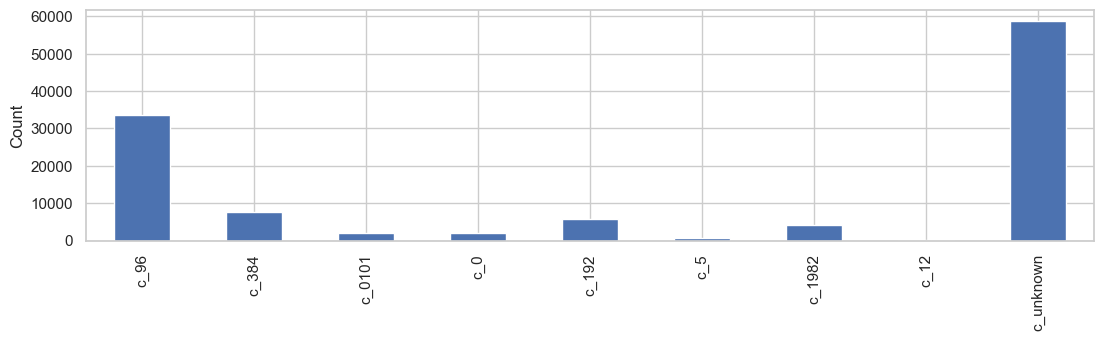

In [21]:
plot_one_category(df, "c")

In [22]:
# Try to reduce the cardinality of the script_name - find the am5, etc...
am_matches = df['exp_name'].str.findall(r'[Aa][Mm]\d+')
am_matches_unique = am_matches.explode().dropna().unique()
am_matches_unique_lower = [s.lower() for s in am_matches_unique]
am_matches_unique_lower

['am5', 'am4', 'am4']

In [23]:
# Create columns corresponding to those unique matches, and basically one-hot encode using them as new column names
for pattern in am_matches_unique_lower:
    df[pattern] = df['exp_name'].apply(
        lambda x: 1 if isinstance(x, str) and pattern in x.lower() else 0
    )

# Create the 'am_unknown' column
# If the sum of all the pattern columns we just created is 0, it's unknown
df['am_unknown'] = (df[am_matches_unique_lower].sum(axis=1) == 0).astype(int)

df.head()

,cpu_time,SLURM_JOB_ACCOUNT,exp_name,exp_time,exp_platform,exp_seg_months,SLURM_JOB_ACCOUNT_cefi,SLURM_JOB_ACCOUNT_gfdl_a,SLURM_JOB_ACCOUNT_gfdl_b,SLURM_JOB_ACCOUNT_gfdl_f,...,c_0101,c_0,c_192,c_5,c_1982,c_12,c_unknown,am5,am4,am_unknown
0,1.297620e+09,gfdl_m,c96L65_am5f8d6r3_pdclim2010F_cosp_CPE2_ens0085,10101,gfdl.ncrc5-intel23-classic,12,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,1,0,0
1,1.527381e+09,gfdl_m,c96L65_am5f8d6r3_pdclim2010F_cosp_CPE2_ens0066,10101,gfdl.ncrc5-intel23-classic,12,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,1,0,0
2,3.506743e+08,gfdl_w,c96L65_am5f8d5r0z_amip_wuopt1,19980101,gfdl.ncrc5-intel23-classic,12,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,1,0,0
3,6.541279e+08,gfdl_m,c96L65_am5f8d6r3_pdclim2010F_cosp_CPE2_ens0085,10101,gfdl.ncrc5-intel23-classic,12,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,1,0,0
4,5.257977e+08,gfdl_m,c96L65_am5f8d6r3_pdclim2010F_cosp_CPE2_ens0066,10101,gfdl.ncrc5-intel23-classic,12,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,1,0,0


In [24]:
# Rename these columns. 'am5' becomes 'am_5'
for col in ['am5', 'am4']:
    new_name = "am_" + col[-1] 
    df.rename(columns={col: new_name}, inplace=True)
df.head()

,cpu_time,SLURM_JOB_ACCOUNT,exp_name,exp_time,exp_platform,exp_seg_months,SLURM_JOB_ACCOUNT_cefi,SLURM_JOB_ACCOUNT_gfdl_a,SLURM_JOB_ACCOUNT_gfdl_b,SLURM_JOB_ACCOUNT_gfdl_f,...,c_0101,c_0,c_192,c_5,c_1982,c_12,c_unknown,am_5,am_4,am_unknown
0,1.297620e+09,gfdl_m,c96L65_am5f8d6r3_pdclim2010F_cosp_CPE2_ens0085,10101,gfdl.ncrc5-intel23-classic,12,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,1,0,0
1,1.527381e+09,gfdl_m,c96L65_am5f8d6r3_pdclim2010F_cosp_CPE2_ens0066,10101,gfdl.ncrc5-intel23-classic,12,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,1,0,0
2,3.506743e+08,gfdl_w,c96L65_am5f8d5r0z_amip_wuopt1,19980101,gfdl.ncrc5-intel23-classic,12,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,1,0,0
3,6.541279e+08,gfdl_m,c96L65_am5f8d6r3_pdclim2010F_cosp_CPE2_ens0085,10101,gfdl.ncrc5-intel23-classic,12,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,1,0,0
4,5.257977e+08,gfdl_m,c96L65_am5f8d6r3_pdclim2010F_cosp_CPE2_ens0066,10101,gfdl.ncrc5-intel23-classic,12,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,1,0,0


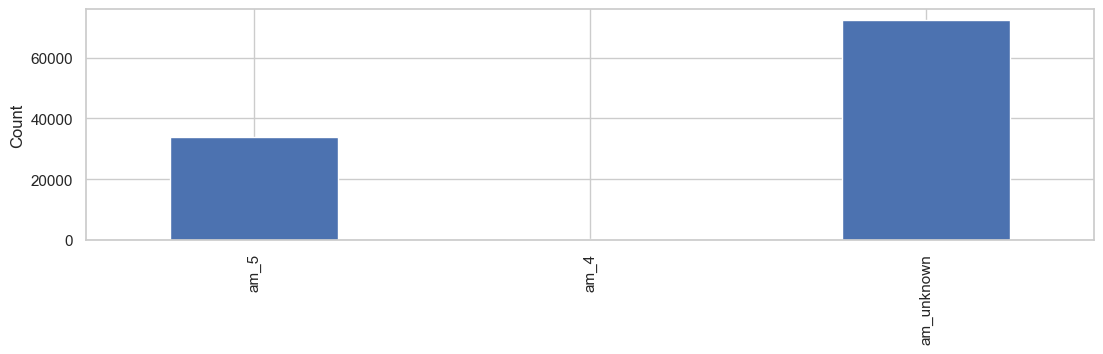

In [25]:
plot_one_category(df, "am")

In [26]:
df = df.drop(columns=['SLURM_JOB_ACCOUNT', 'exp_name', 'exp_platform'])

In [27]:
df.columns.tolist()

['cpu_time',
 'exp_time',
 'exp_seg_months',
 'SLURM_JOB_ACCOUNT_cefi',
 'SLURM_JOB_ACCOUNT_gfdl_a',
 'SLURM_JOB_ACCOUNT_gfdl_b',
 'SLURM_JOB_ACCOUNT_gfdl_f',
 'SLURM_JOB_ACCOUNT_gfdl_m',
 'SLURM_JOB_ACCOUNT_gfdl_o',
 'SLURM_JOB_ACCOUNT_gfdl_sd',
 'SLURM_JOB_ACCOUNT_gfdl_w',
 'exp_target_prod',
 'exp_target_prod,hdf5',
 'exp_target_prod-hdf5',
 'exp_target_prod-openmp',
 'exp_target_repro',
 'exp_target_repro-openmp',
 'exp_platform_gfdl.ncrc2-intel',
 'exp_platform_gfdl.ncrc5-deploy',
 'exp_platform_gfdl.ncrc5-intel-classic',
 'exp_platform_gfdl.ncrc5-intel-classic_202302',
 'exp_platform_gfdl.ncrc5-intel22',
 'exp_platform_gfdl.ncrc5-intel23',
 'exp_platform_gfdl.ncrc5-intel23-classic',
 'exp_platform_gfdl.ncrc5-intel23_2_0',
 'exp_platform_gfdl.ncrc5-intel25',
 'exp_platform_gfdl.ncrc5-intel25-MM',
 'exp_platform_gfdl.ncrc5-inteloneapi252',
 'exp_platform_gfdl.ncrc6-intel23',
 'exp_platform_gfdl.ncrc6-intel23_2_0',
 'exp_platform_gfdl.ncrc6-intel25',
 'exp_component_LUmip',
 'exp_co

In [28]:
all_cols = df.columns.tolist()
target_col = ['cpu_time']
num_cols = ['exp_time', 'exp_seg_months']
cat_cols = list(set(all_cols) - set(num_cols) - set(target_col))

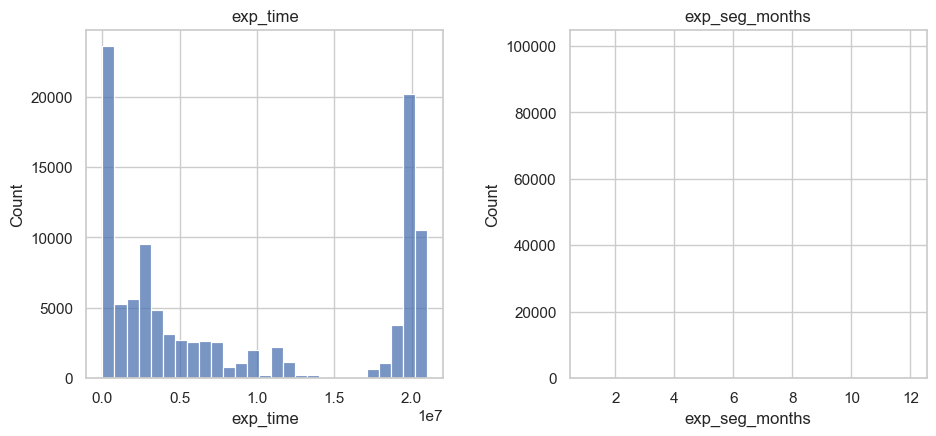

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout(pad=2.5)

In [30]:
df = df.drop(columns=['exp_seg_months']) # REMOVE until we have more...

In [31]:
all_cols = df.columns.tolist()
target_col = ['cpu_time']
num_cols = ['exp_time']
cat_cols = list(set(all_cols) - set(num_cols) - set(target_col))

## Split Data for Train, Validate, Final Test
* Work with training and validation data first.
* Save the final testing data for later.

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.ensemble import VotingRegressor

from sklearn.model_selection import GridSearchCV

In [33]:
target = 'cpu_time'
X = df.drop(target, axis=1)
y = df[target]

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)

## Handling Skew and Outliers

In [34]:
df[['exp_time']].skew().sort_values(ascending=False)

exp_time    0.407801
dtype: float64

In [35]:
df['exp_time'] = np.log1p(df['exp_time'])

In [36]:
scaler = StandardScaler()
df['exp_time'] = scaler.fit_transform(df[['exp_time']])

## Looking at Correlations

In [37]:
df.corr(numeric_only=True)['cpu_time'].sort_values(ascending=False)

cpu_time                                        1.000000
exp_platform_gfdl.ncrc6-intel25                 0.113335
c_384                                           0.110158
c_5                                             0.097912
exp_platform_gfdl.ncrc5-intel-classic_202302    0.097912
SLURM_JOB_ACCOUNT_gfdl_b                        0.090915
exp_target_prod-openmp                          0.067898
exp_component_atmos                             0.040401
SLURM_JOB_ACCOUNT_gfdl_sd                       0.034755
exp_target_repro-openmp                         0.032867
exp_time                                        0.031609
exp_platform_gfdl.ncrc6-intel23_2_0             0.030277
exp_platform_gfdl.ncrc2-intel                   0.026415
exp_component_ocean                             0.024838
c_1982                                          0.022670
c_192                                           0.021765
exp_component_soil                              0.020930
exp_platform_gfdl.ncrc5-deploy 

### Linear Regression Model

In [38]:
lr_model = make_pipeline(
    LinearRegression()
)

lr_model.fit(X_train, y_train)

lr_val_pred = lr_model.predict(X_val)
lr_mse = mean_squared_error(y_val, lr_val_pred)
lr_r2 = r2_score(y_val, lr_val_pred)

print(f"Mean Squared Error: {lr_mse:.2f}")
print(f"R-squared Score: {lr_r2:.2f}")

Mean Squared Error: 2928154865759201792.00
R-squared Score: 0.07


### MLP

In [39]:
mlp_model = make_pipeline(
    MLPRegressor(hidden_layer_sizes=(20, 20), max_iter=5000, random_state=42)
)

mlp_model.fit(X_train, y_train)

mlp_val_pred = mlp_model.predict(X_val)
mlp_mse = mean_squared_error(y_val, mlp_val_pred)
mlp_r2 = r2_score(y_val, mlp_val_pred)

print(f"Mean Squared Error: {mlp_mse:.2f}")
print(f"R-squared Score: {mlp_r2:.2f}")

Mean Squared Error: 3258495474444389888.00
R-squared Score: -0.04


### Decision Tree

In [40]:
dtree_model = make_pipeline(
    DecisionTreeRegressor(max_depth=15, min_samples_split=5)
)

dtree_model.fit(X_train, y_train)

dtree_val_pred = dtree_model.predict(X_val)
dtree_mse = mean_squared_error(y_val, dtree_val_pred)
dtree_r2 = r2_score(y_val, dtree_val_pred)

print(f"Mean Squared Error: {dtree_mse:.2f}")
print(f"R-squared Score: {dtree_r2:.2f}")

Mean Squared Error: 2088617223749001216.00
R-squared Score: 0.34


## Bagging vs Boosting
* Multiple models independent of eachother, average voting
* Multiple models trained sequentially, weighted voting

https://www.geeksforgeeks.org/machine-learning/bagging-vs-boosting-in-machine-learning/

In [41]:
rf_model = RandomForestRegressor(n_estimators=10, max_depth=15, random_state=42)

rf_model.fit(X_train, y_train)

rf_val_pred = rf_model.predict(X_val)
rf_mse = mean_squared_error(y_val, rf_val_pred)
rf_r2 = r2_score(y_val, rf_val_pred)

print(f"Mean Squared Error: {rf_mse:.2f}")
print(f"R-squared Score: {rf_r2:.2f}")

Mean Squared Error: 2024427165193665792.00
R-squared Score: 0.36


In [42]:
gb_model = HistGradientBoostingRegressor(max_iter=100, learning_rate=0.1, max_depth=10, random_state=42)
gb_model.fit(X_train, y_train)

gb_val_pred = gb_model.predict(X_val)
gb_mse = mean_squared_error(y_val, gb_val_pred)
gb_r2 = r2_score(y_val, gb_val_pred)

print(f"Mean Squared Error: {gb_mse:.2f}")
print(f"R-squared Score: {gb_r2:.2f}")

Mean Squared Error: 1967070432466382336.00
R-squared Score: 0.38


In [43]:
from sklearn.ensemble import VotingRegressor

ensemble = VotingRegressor(estimators=[
    #('rf', rf_model), 
    #('dtree', dtree_model), 
    #('lr', lr_model),
    ('gb', gb_model),
    #('mlp', mlp_model)
])
ensemble.fit(X_train, y_train)
predictions = ensemble.predict(X_val)

mse = mean_squared_error(y_val, predictions)
r2 = r2_score(y_val, predictions)
print(f"Mean Squared Error: {mse:.4f}")
print(f"R-squared Score: {r2:.2f}")

Mean Squared Error: 1967070432466382336.0000
R-squared Score: 0.38


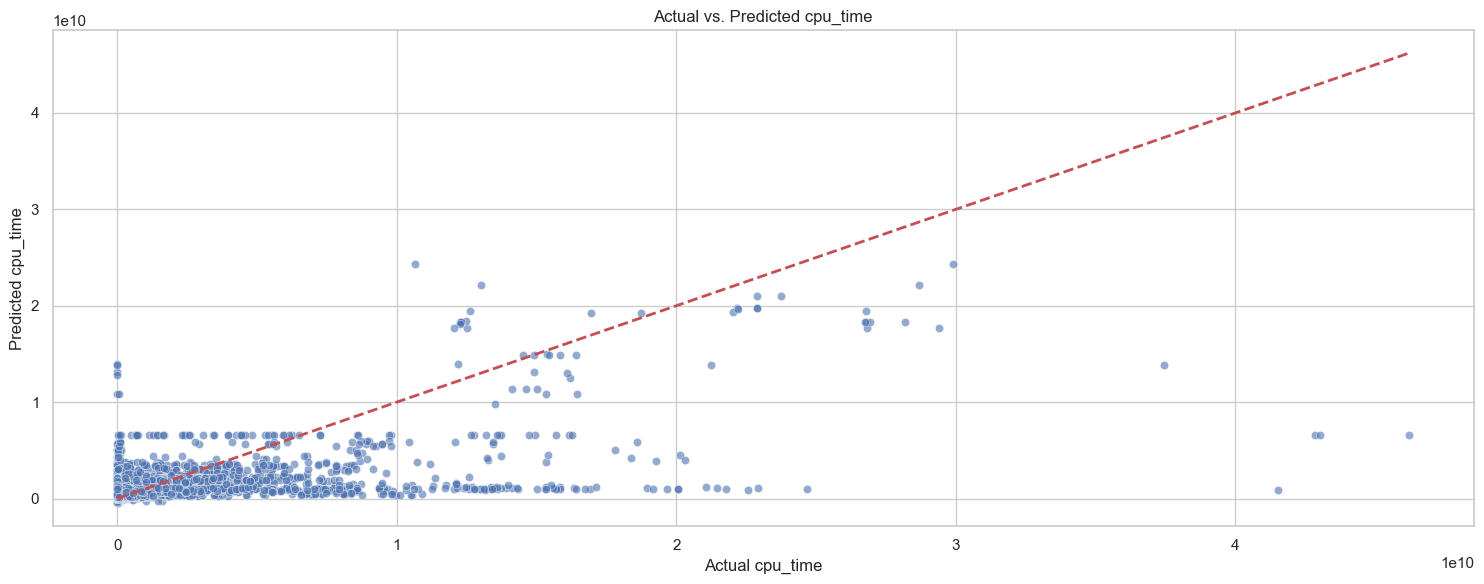

In [44]:
sns.set_theme(style="whitegrid")

fig, ax1 = plt.subplots(1, 1, figsize=(15, 6))

sns.scatterplot(x=y_val, y=predictions, ax=ax1, alpha=0.6)
ax1.plot([y_test.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2) # Diagonal line
ax1.set_title(f'Actual vs. Predicted {target}')
ax1.set_xlabel(f'Actual {target}')
ax1.set_ylabel(f'Predicted {target}')

plt.tight_layout()
plt.show()

## Try to learn something about the best and worst predictions

In [45]:
residuals = y_val - predictions
abs_error = np.abs(residuals)

df_results = pd.DataFrame({
    "actual": y_val,
    "predictions": predictions,
    "residuals": residuals,
    "abs_error": abs_error,
})

In [46]:
n = 5
best_n = df_results.sort_values("abs_error").head(n)
best_n

,actual,predictions,residuals,abs_error
78100,42544485.0,4.255331e+07,-8824.779546,8824.779546
66135,495215990.0,4.952283e+08,-12290.120761,12290.120761
3873,48434671.0,4.841388e+07,20791.415273,20791.415273
27556,55670717.0,5.570440e+07,-33687.121799,33687.121799
52771,84665375.0,8.462034e+07,45037.972022,45037.972022


In [47]:
n = 5
best_n = df_results.sort_values("abs_error", ascending=False).head(n)
best_n

,actual,predictions,residuals,abs_error
40736,4.152062e+10,9.324914e+08,4.058813e+10,4.058813e+10
25715,4.622387e+10,6.557544e+09,3.966632e+10,3.966632e+10
16659,4.304021e+10,6.557544e+09,3.648266e+10,3.648266e+10
81750,4.283199e+10,6.557544e+09,3.627445e+10,3.627445e+10
17800,2.466057e+10,1.032199e+09,2.362837e+10,2.362837e+10


## Hyperparameter Tuning

In [48]:
'''
param_grid = {
    'max_depth': [None, 10, 15, 20, 25, 30, 50],
    'learning_rate': [0.01, 0.1, 0.2, 0.25, 0.3],
    'max_iter': [50, 100, 200, 300, 400],
}

grid_search = GridSearchCV(HistGradientBoostingRegressor(random_state=42), param_grid, cv=5, scoring='r2')
grid_search.fit(X_train, y_train)

print(f"Best R-squared from Grid Search: {grid_search.best_score_:.4f}")
print(grid_search.best_params_)
'''
# Best R-squared from Grid Search: 0.3627
# {'learning_rate': 0.1, 'max_depth': 10, 'max_iter': 100}

'\nparam_grid = {\n    \'max_depth\': [None, 10, 15, 20, 25, 30, 50],\n    \'learning_rate\': [0.01, 0.1, 0.2, 0.25, 0.3],\n    \'max_iter\': [50, 100, 200, 300, 400],\n}\n\ngrid_search = GridSearchCV(HistGradientBoostingRegressor(random_state=42), param_grid, cv=5, scoring=\'r2\')\ngrid_search.fit(X_train, y_train)\n\nprint(f"Best R-squared from Grid Search: {grid_search.best_score_:.4f}")\nprint(grid_search.best_params_)\n'

## Predicting Testing Set

Interestingly, the r_squared on the final test data is better than the validation set.

In [49]:
test_predictions = ensemble.predict(X_test)

test_mse = mean_squared_error(y_test, test_predictions)
test_r2 = r2_score(y_test, test_predictions)
print(f"Mean Squared Error: {test_mse:.4f}")
print(f"R-squared Score: {test_r2:.2f}")

Mean Squared Error: 1863605131905284352.0000
R-squared Score: 0.42


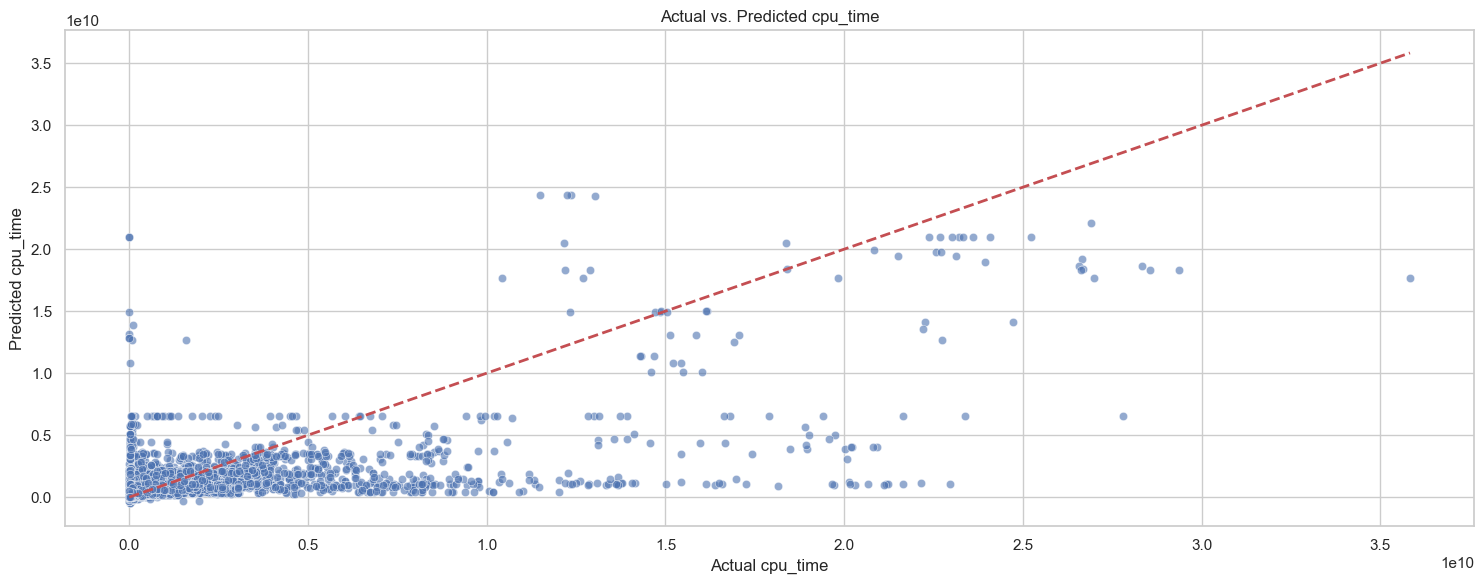

In [50]:
fig, ax1 = plt.subplots(1, 1, figsize=(15, 6))

sns.scatterplot(x=y_test, y=test_predictions, ax=ax1, alpha=0.6)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Diagonal line
ax1.set_title(f'Actual vs. Predicted {target}')
ax1.set_xlabel(f'Actual {target}')
ax1.set_ylabel(f'Predicted {target}')

plt.tight_layout()
plt.show()

In [51]:
# Possible next steps ---
# TODO: 4. maybe try break up "ocean" exp_component --- even further... 
# TODO: 6. More Hyper-parameter tuning
# TODO: 8. Try removing log and going again... maybe standarization for everything rather than log....
# TODO: 9. Try adding back in group data... just to see...
# TODO: 10. Try limiting features based on all "exp_component" or all another group of features rather than single highest correlated values.
# TODO: 11. I can get more data --- query more... can ask ian for db support (note: querying after 3 weeks is good, possibly use "before=-21" in get_jobs in epmt_query.py) --- double-check please
# TODO: 12. Try out epmt 5.0.0!!!!! (higher priority)
